In [115]:
import random
import numpy as np
import matplotlib.pyplot as plt

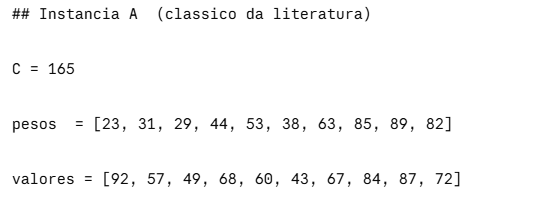

In [ ]:
itens = [f'x{i}' for i in range(10)]
print(itens)
C = 165
pesos = [23,31,29,44,53,38,63,85,89,82]
valores = [92,57,49,68,60,43,67,84,87,72]

['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']


In [ ]:
[0,1,1,0,1,0,1,0]

In [3]:
# Definir o problema
def func_obj(itens):
    fo = np.sum([itens[i] * valores[i] for i in range(len(itens))])
    return fo
# restrições
def rest(itens):
    res = np.sum([itens[i] * pesos[i] for i in range(len(itens))]) <= C
    return res

In [ ]:
def ga(populacao_tamanho,num_geracoes):

    # ----------------------------------------------------
    #-- Inicialization
    #  criar uma lista de população e preencher
    #  criar uma função "fitness" que checa o valor(fo) da população 
    population = []  # primeira população a ser criada
    fitness_history = [] 

    # aqui eu tenho q preenhcer essa população com valores randomizados de cada x do itens
    for i in range(populacao_tamanho):
        lista_previa_pop = []
        for j in range(len(pesos)):
            x = random.randint(0,1)
            lista_previa_pop.append(x)
        population.append(lista_previa_pop)

    best_solution = None
    best_fitness = float('-inf')

    for n_gen in range(num_geracoes):
        # ----------------------------------------------------
        #Evaluation
        
        # aqui eu vou cirar uma lista que vai ter os valores da função objetivo para a pop criada
        # nessa fitness eu vou calcular a fo para cada lista continda na população
        # criar uma feasible population, por conta das restrições

        fitness = [func_obj(x) for x in population]
        feasible_population = [individuo for individuo in population if rest(individuo)]

        # ----------------------------------------------------
        #Selection
        
        # Aqui eu vou olhar a feasible_population
        # calcular a FO baseado na population que é ok na restrição
        if feasible_population:  #ou seja, se existir alguma lista que é ok na restrição
            feasible_fitness = [func_obj(x) for x in feasible_population]
            parents = random.choices(feasible_population,weights=feasible_fitness,k=populacao_tamanho)
        else: #aqui eu tenho q criar um Else para caso nao tenha feasible population
            parents = random.choices(population,weights=fitness,k=populacao_tamanho)
            # VALOR_POTENTIAL_PARENTS = [rest(x) for x in parents]

        # ----------------------------------------------------
        #Crossover 
        # aqui é criar os descendentes (offspring)
        # no meu caso particular, sao listas os pais, e gero um filho composto pr [0:2] e [2:]
        # mas poderia gerar 2 filhos, só que ai o range(populacao_tamanho) tem q ser divido por 2, para manter a população nova no mesmo tamanho
        offspring = []

        for i in range(populacao_tamanho):
            parent1,parent2 = random.choices(parents,k=2)
            filho = parent1[:2]+parent2[2:]
            # filho2 = parent2[:2]+parent1[2:]
            offspring.append(filho)
        # print(f"Filho: {filho1}")

        # ----------------------------------------------------   
        #Mutation
        # Aqui vai ser a mudança dos valores dos offspring
        taxa_mutacao = 0.10  #valores dinamicos de tx
        # taxa_mutacao = 1/(n_gen+1)  #valores dinamicos de tx
        for i in range(len(offspring)):
            for j in range(len(offspring[i])):
                if random.random() < taxa_mutacao:
                    offspring[i][j] = random.randint(0,1)

        # ----------------------------------------------------
        #Elitism
        #checar para primeira passagem se nao tem best_solution
        if best_solution is not None:
            offspring[0] = best_solution

        population = offspring

        # ----------------------------------------------------
        # Encontrar as melhores soluções

        feasible_solutions = [x for x in population if rest(x)]
        if feasible_solutions: # se existir solucoes possiveis
            best_solution = max(feasible_solutions,key= lambda x: func_obj(x))
            best_fitness = func_obj(best_solution)
        fitness_history.append(best_fitness)
        print(f"Geração {n_gen+1}: Best Solution = {best_solution}, Best fitness: {best_fitness}")

    #plotagem
    plt.plot(range(1,num_geracoes+1),fitness_history)
    plt.show()
    return best_solution,best_fitness

Geração 1: Best Solution = [1, 0, 1, 1, 0, 0, 1, 0, 0, 0], Best fitness: 276
Geração 2: Best Solution = [1, 0, 1, 1, 0, 0, 1, 0, 0, 0], Best fitness: 276
Geração 3: Best Solution = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0], Best fitness: 284
Geração 4: Best Solution = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0], Best fitness: 284
Geração 5: Best Solution = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0], Best fitness: 284
Geração 6: Best Solution = [1, 1, 0, 1, 0, 0, 1, 0, 0, 0], Best fitness: 284
Geração 7: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 8: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 9: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 10: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 11: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 12: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness: 309
Geração 13: Best Solution = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], Best fitness:

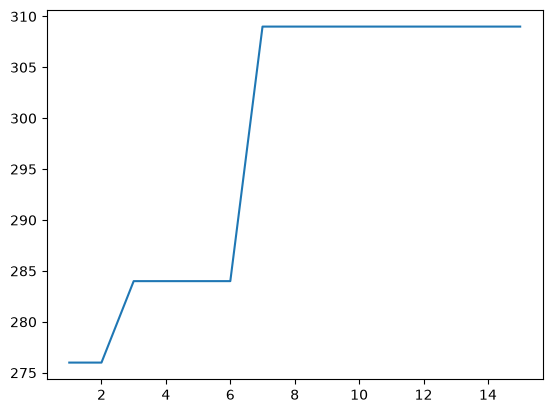

([1, 1, 1, 1, 0, 1, 0, 0, 0, 0], np.int64(309))

In [162]:
ga(50,15)